Training classifier for evaluation...
Classifier Epoch 1/5, Accuracy: 79.87%
Classifier Epoch 2/5, Accuracy: 84.91%
Classifier Epoch 3/5, Accuracy: 86.26%
Classifier Epoch 4/5, Accuracy: 86.91%
Classifier Epoch 5/5, Accuracy: 87.44%
Epoch [1/50] | D loss: 0.2033 | G loss: 3.4361
Epoch [2/50] | D loss: 0.2712 | G loss: 3.3353
Epoch [3/50] | D loss: 0.2774 | G loss: 3.1431
Epoch [4/50] | D loss: 0.3502 | G loss: 2.6772
Epoch [5/50] | D loss: 0.3655 | G loss: 2.4192
Epoch [6/50] | D loss: 0.4134 | G loss: 2.2268
Epoch [7/50] | D loss: 0.4456 | G loss: 2.0505
Epoch [8/50] | D loss: 0.4582 | G loss: 1.9380
Epoch [9/50] | D loss: 0.4830 | G loss: 1.7758
Epoch [10/50] | D loss: 0.4960 | G loss: 1.7118

Evaluating GAN Performance...
Inception Score: 5.5811 ± 0.1919
Conditional Accuracy: 83.70%
Mode Coverage: 100.00%
FID Score: 43.6473
Discriminator Confidence on Generated: 0.2799

Epoch [11/50] | D loss: 0.5081 | G loss: 1.5992
Epoch [12/50] | D loss: 0.5293 | G loss: 1.5526
Epoch [13/50] | D 

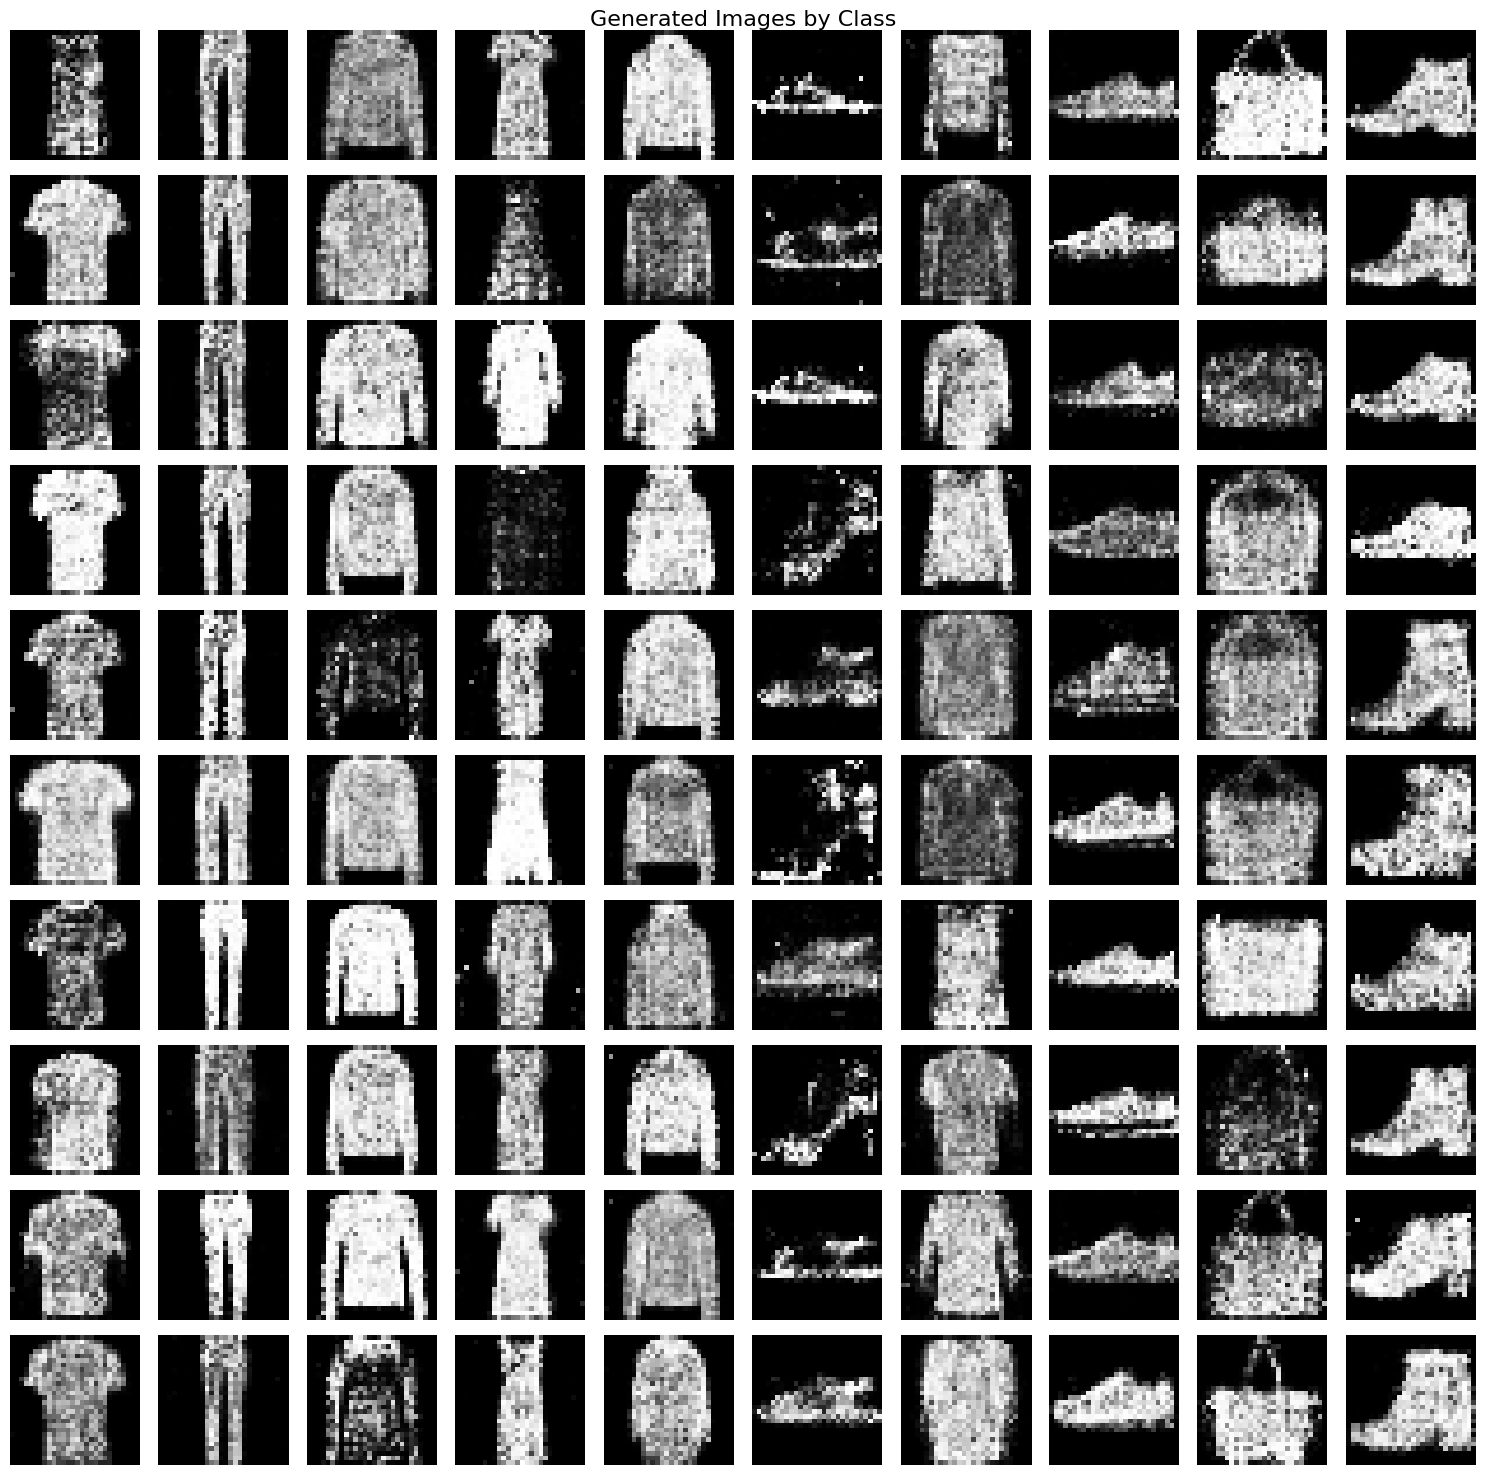

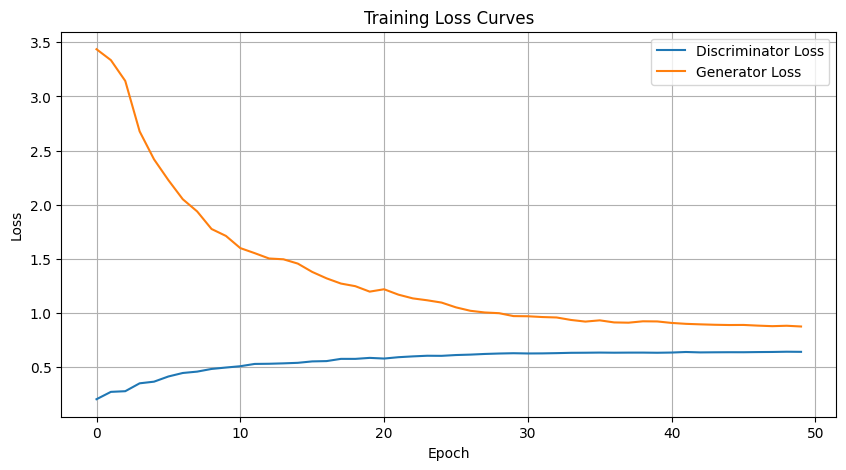


Training completed!


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from scipy.linalg import sqrtm
from sklearn.metrics import accuracy_score

# -----------------------------
# 1. 超参数
# -----------------------------
batch_size = 128
z_dim = 100
num_classes = 10
lr = 0.0002
epochs = 50  # 增加训练轮数
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -----------------------------
# 2. 数据加载 (Fashion-MNIST)
# -----------------------------
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.FashionMNIST(root="./data", train=True, transform=transform, download=True)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# 加载测试集用于评估
test_dataset = datasets.FashionMNIST(root="./data", train=False, transform=transform, download=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# -----------------------------
# 3. 模型定义
# -----------------------------
class Generator(nn.Module):
    def __init__(self, z_dim, num_classes, img_shape=28*28):
        super().__init__()
        self.label_emb = nn.Embedding(num_classes, num_classes)
        self.model = nn.Sequential(
            nn.Linear(z_dim + num_classes, 256),
            nn.ReLU(True),
            nn.Linear(256, 512),
            nn.ReLU(True),
            nn.Linear(512, img_shape),
            nn.Tanh()
        )
    def forward(self, z, labels):
        c = self.label_emb(labels)
        x = torch.cat([z, c], dim=1)
        img = self.model(x)
        return img.view(img.size(0), 1, 28, 28)

class Discriminator(nn.Module):
    def __init__(self, num_classes, img_shape=28*28):
        super().__init__()
        self.label_emb = nn.Embedding(num_classes, num_classes)
        self.model = nn.Sequential(
            nn.Linear(img_shape + num_classes, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )
    def forward(self, img, labels):
        c = self.label_emb(labels)
        x = torch.cat([img.view(img.size(0), -1), c], dim=1)
        return self.model(x)

# -----------------------------
# 4. 评估分类器（用于计算Inception Score和分类准确率）
# -----------------------------
class Classifier(nn.Module):
    """简单的分类器用于评估生成图像"""
    def __init__(self, num_classes):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
    
    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.model(x)

def train_classifier():
    """训练一个分类器用于评估"""
    print("Training classifier for evaluation...")
    classifier = Classifier(num_classes).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(classifier.parameters(), lr=0.001)
    
    classifier.train()
    for epoch in range(5):
        correct = 0
        total = 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = classifier(imgs)
            loss = criterion(outputs, labels)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
        
        acc = 100 * correct / total
        print(f"Classifier Epoch {epoch+1}/5, Accuracy: {acc:.2f}%")
    
    return classifier

# -----------------------------
# 5. 质量评价指标
# -----------------------------
def calculate_inception_score(gen_imgs, classifier, n_split=10, eps=1e-16):
    """
    计算Inception Score (IS)
    IS越高表示生成图像质量越好且多样性越高
    """
    classifier.eval()
    with torch.no_grad():
        preds = torch.softmax(classifier(gen_imgs), dim=1).cpu().numpy()
    
    # 分割成多个部分计算
    split_scores = []
    n_part = preds.shape[0] // n_split
    
    for i in range(n_split):
        part = preds[i * n_part:(i + 1) * n_part]
        py = np.mean(part, axis=0)  # 边际分布
        scores = []
        for j in range(part.shape[0]):
            pyx = part[j]
            scores.append(np.sum(pyx * np.log(pyx / (py + eps) + eps)))
        split_scores.append(np.exp(np.mean(scores)))
    
    return np.mean(split_scores), np.std(split_scores)

def calculate_fid(real_features, fake_features):
    """
    计算Fréchet Inception Distance (FID)
    FID越低表示生成图像与真实图像分布越接近
    """
    mu1, sigma1 = real_features.mean(axis=0), np.cov(real_features, rowvar=False)
    mu2, sigma2 = fake_features.mean(axis=0), np.cov(fake_features, rowvar=False)
    
    ssdiff = np.sum((mu1 - mu2) ** 2.0)
    covmean = sqrtm(sigma1.dot(sigma2))
    
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    
    fid = ssdiff + np.trace(sigma1 + sigma2 - 2.0 * covmean)
    return fid

def extract_features(imgs, model):
    """提取特征用于FID计算"""
    model.eval()
    with torch.no_grad():
        # 使用分类器的倒数第二层作为特征
        x = imgs.view(imgs.size(0), -1)
        for layer in list(model.model.children())[:-1]:
            x = layer(x)
        return x.cpu().numpy()

def calculate_mode_score(gen_labels, num_classes):
    """
    计算模式覆盖率
    衡量生成器是否能生成所有类别的样本
    """
    unique_labels = len(np.unique(gen_labels))
    mode_coverage = unique_labels / num_classes
    return mode_coverage

def calculate_conditional_accuracy(G, classifier, num_samples=1000):
    """
    计算条件准确率
    衡量生成的图像是否符合给定的类别标签
    """
    G.eval()
    classifier.eval()
    
    all_true_labels = []
    all_pred_labels = []
    
    with torch.no_grad():
        for _ in range(num_samples // num_classes):
            z = torch.randn(num_classes, z_dim, device=device)
            labels = torch.arange(0, num_classes, device=device)
            gen_imgs = G(z, labels)
            
            outputs = classifier(gen_imgs)
            _, predicted = torch.max(outputs.data, 1)
            
            all_true_labels.extend(labels.cpu().numpy())
            all_pred_labels.extend(predicted.cpu().numpy())
    
    accuracy = accuracy_score(all_true_labels, all_pred_labels)
    return accuracy

def evaluate_gan(G, D, classifier, test_loader, num_samples=1000):
    """综合评估GAN性能"""
    print("\n" + "="*50)
    print("Evaluating GAN Performance...")
    print("="*50)
    
    G.eval()
    
    # 1. 生成样本
    with torch.no_grad():
        z = torch.randn(num_samples, z_dim, device=device)
        gen_labels = torch.randint(0, num_classes, (num_samples,), device=device)
        gen_imgs = G(z, gen_labels)
    
    # 2. Inception Score
    is_mean, is_std = calculate_inception_score(gen_imgs, classifier)
    print(f"Inception Score: {is_mean:.4f} ± {is_std:.4f}")
    
    # 3. 条件准确率
    cond_acc = calculate_conditional_accuracy(G, classifier, num_samples)
    print(f"Conditional Accuracy: {cond_acc*100:.2f}%")
    
    # 4. 模式覆盖率
    mode_cov = calculate_mode_score(gen_labels.cpu().numpy(), num_classes)
    print(f"Mode Coverage: {mode_cov*100:.2f}%")
    
    # 5. FID Score
    # 提取真实图像特征
    real_features_list = []
    for imgs, _ in test_loader:
        imgs = imgs.to(device)
        features = extract_features(imgs, classifier)
        real_features_list.append(features)
        if len(real_features_list) * batch_size >= num_samples:
            break
    real_features = np.vstack(real_features_list)[:num_samples]
    
    # 提取生成图像特征
    fake_features = extract_features(gen_imgs, classifier)
    
    fid_score = calculate_fid(real_features, fake_features)
    print(f"FID Score: {fid_score:.4f}")
    
    # 6. 判别器置信度
    with torch.no_grad():
        d_real_conf = D(gen_imgs, gen_labels).mean().item()
    print(f"Discriminator Confidence on Generated: {d_real_conf:.4f}")
    
    print("="*50 + "\n")
    
    return {
        'is_mean': is_mean,
        'is_std': is_std,
        'cond_acc': cond_acc,
        'mode_cov': mode_cov,
        'fid': fid_score,
        'd_conf': d_real_conf
    }

# -----------------------------
# 6. 初始化模型与优化器
# -----------------------------
G = Generator(z_dim, num_classes).to(device)
D = Discriminator(num_classes).to(device)
criterion = nn.BCELoss()
optimizer_G = optim.Adam(G.parameters(), lr=lr, betas=(0.5, 0.999))
optimizer_D = optim.Adam(D.parameters(), lr=lr, betas=(0.5, 0.999))

# 训练评估分类器
classifier = train_classifier()

# -----------------------------
# 7. 训练循环（带评估）
# -----------------------------
history = {'d_loss': [], 'g_loss': [], 'metrics': []}

for epoch in range(epochs):
    G.train()
    D.train()
    
    epoch_d_loss = 0
    epoch_g_loss = 0
    num_batches = 0
    
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        batch_size = imgs.size(0)

        # 真/假标签
        real = torch.ones(batch_size, 1, device=device)
        fake = torch.zeros(batch_size, 1, device=device)

        # 训练判别器 D
        z = torch.randn(batch_size, z_dim, device=device)
        fake_labels = torch.randint(0, num_classes, (batch_size,), device=device)
        fake_imgs = G(z, fake_labels)

        real_loss = criterion(D(imgs, labels), real)
        fake_loss = criterion(D(fake_imgs.detach(), fake_labels), fake)
        d_loss = (real_loss + fake_loss) / 2

        optimizer_D.zero_grad()
        d_loss.backward()
        optimizer_D.step()

        # 训练生成器 G
        z = torch.randn(batch_size, z_dim, device=device)
        gen_labels = torch.randint(0, num_classes, (batch_size,), device=device)
        gen_imgs = G(z, gen_labels)
        g_loss = criterion(D(gen_imgs, gen_labels), real)

        optimizer_G.zero_grad()
        g_loss.backward()
        optimizer_G.step()
        
        epoch_d_loss += d_loss.item()
        epoch_g_loss += g_loss.item()
        num_batches += 1

    avg_d_loss = epoch_d_loss / num_batches
    avg_g_loss = epoch_g_loss / num_batches
    history['d_loss'].append(avg_d_loss)
    history['g_loss'].append(avg_g_loss)
    
    print(f"Epoch [{epoch+1}/{epochs}] | D loss: {avg_d_loss:.4f} | G loss: {avg_g_loss:.4f}")
    
    # 每10个epoch评估一次
    if (epoch + 1) % 10 == 0:
        metrics = evaluate_gan(G, D, classifier, test_loader)
        history['metrics'].append(metrics)

# -----------------------------
# 8. 最终评估
# -----------------------------
final_metrics = evaluate_gan(G, D, classifier, test_loader)

# -----------------------------
# 9. 可视化结果
# -----------------------------
# 生成每个类别的样本
G.eval()
with torch.no_grad():
    z = torch.randn(num_classes * 10, z_dim, device=device)
    labels = torch.arange(0, num_classes, device=device).repeat(10)
    gen_imgs = G(z, labels).cpu()

# 绘制生成样本网格
fig, axes = plt.subplots(num_classes, 10, figsize=(15, 15))
for i in range(num_classes):
    for j in range(10):
        idx = i * 10 + j
        axes[i, j].imshow(gen_imgs[idx].squeeze() * 0.5 + 0.5, cmap='gray')
        axes[i, j].axis('off')
        if j == 0:
            axes[i, j].set_ylabel(f'Class {i}', fontsize=12)

plt.suptitle('Generated Images by Class', fontsize=16)
plt.tight_layout()
plt.show()

# 绘制训练损失曲线
plt.figure(figsize=(10, 5))
plt.plot(history['d_loss'], label='Discriminator Loss')
plt.plot(history['g_loss'], label='Generator Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Curves')
plt.legend()
plt.grid(True)
plt.show()

print("\nTraining completed!")

Training classifier for evaluation...
Classifier Epoch 1/5, Accuracy: 79.82%
Classifier Epoch 2/5, Accuracy: 84.82%
Classifier Epoch 3/5, Accuracy: 86.11%
Classifier Epoch 4/5, Accuracy: 86.90%
Classifier Epoch 5/5, Accuracy: 87.54%
Epoch [1/50] | D loss: 0.1766 | G loss: 3.7171
Epoch [2/50] | D loss: 0.2658 | G loss: 3.5572
Epoch [3/50] | D loss: 0.2911 | G loss: 3.0781
Epoch [4/50] | D loss: 0.3870 | G loss: 2.5005
Epoch [5/50] | D loss: 0.4180 | G loss: 2.1732
Epoch [6/50] | D loss: 0.4049 | G loss: 2.2425
Epoch [7/50] | D loss: 0.4168 | G loss: 2.1707
Epoch [8/50] | D loss: 0.4300 | G loss: 2.0135
Epoch [9/50] | D loss: 0.4464 | G loss: 1.8866
Epoch [10/50] | D loss: 0.4763 | G loss: 1.6950

Evaluating GAN Performance...
Inception Score: 6.2915 ± 0.3466
Conditional Accuracy: 86.80%
Mode Coverage: 100.00%
FID Score: 26.5029
Discriminator Confidence on Generated: 0.3322

Epoch [11/50] | D loss: 0.4832 | G loss: 1.6810
Epoch [12/50] | D loss: 0.4861 | G loss: 1.6065
Epoch [13/50] | D 

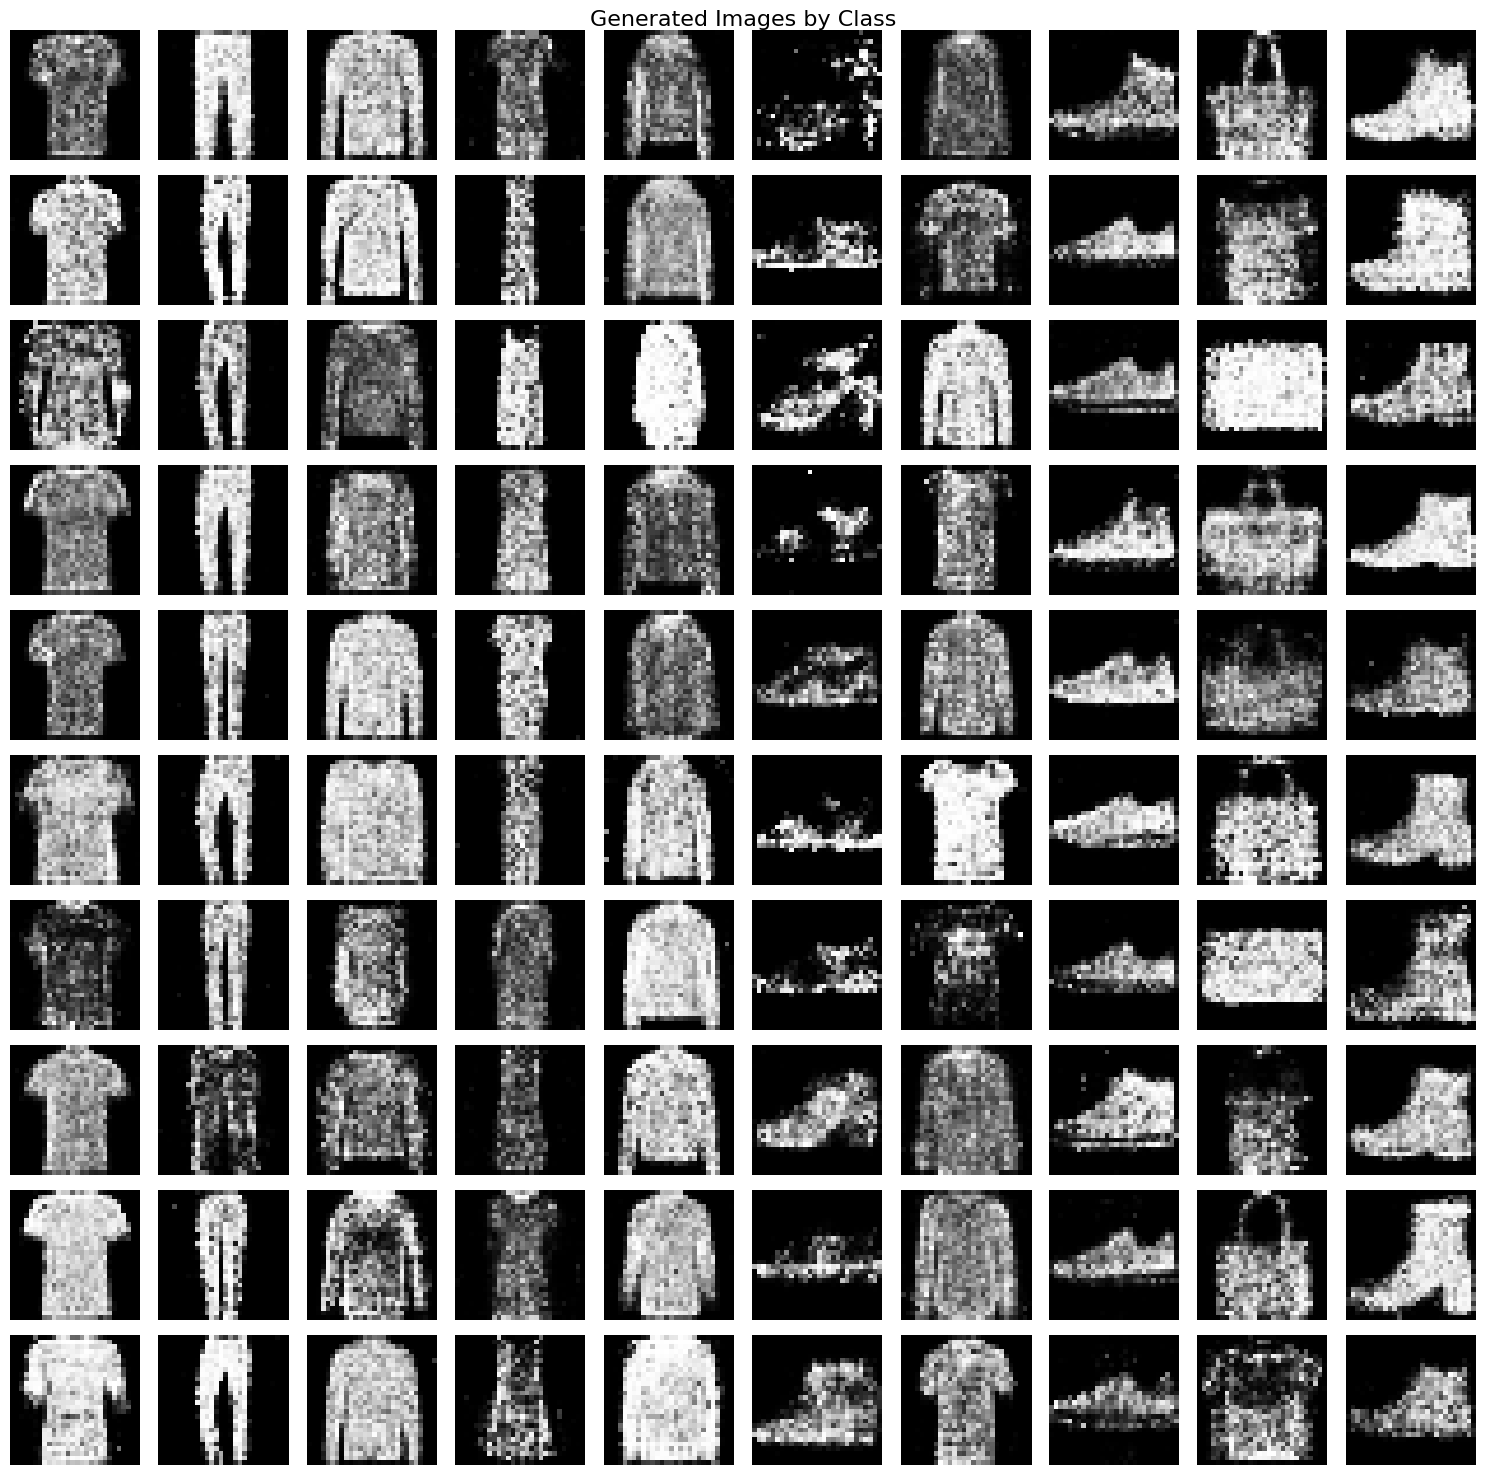

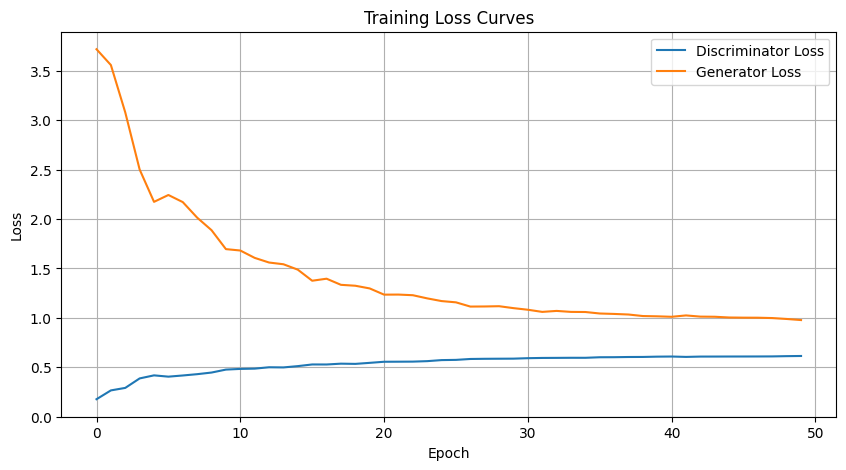


Training completed!


In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from scipy.linalg import sqrtm
from sklearn.metrics import accuracy_score

# -----------------------------
# 1. 超参数
# -----------------------------
batch_size = 128
z_dim = 100
num_classes = 10
lr = 0.0002
epochs = 50  # 增加训练轮数
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -----------------------------
# 2. 数据加载 (Fashion-MNIST)
# -----------------------------
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.FashionMNIST(root="./data", train=True, transform=transform, download=True)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# 加载测试集用于评估
test_dataset = datasets.FashionMNIST(root="./data", train=False, transform=transform, download=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# -----------------------------
# 3. 模型定义
# -----------------------------
class Generator(nn.Module):
    def __init__(self, z_dim, num_classes, img_shape=28*28):
        super().__init__()
        self.label_emb = nn.Embedding(num_classes, num_classes)
        self.model = nn.Sequential(
            nn.Linear(z_dim + num_classes, 256),
            nn.ReLU(True),
            nn.Linear(256, 512),
            nn.ReLU(True),
            nn.Linear(512, img_shape),
            nn.Tanh()
        )
    def forward(self, z, labels):
        c = self.label_emb(labels)
        x = torch.cat([z, c], dim=1)
        img = self.model(x)
        return img.view(img.size(0), 1, 28, 28)


class Vsig(nn.Module):
    def __init__(self, init_sigma=0.3):
        super(Vsig, self).__init__()
        self.sigma = nn.Parameter(torch.tensor(init_sigma, dtype=torch.float32))
    
    def forward(self, input):
        eps = 1e-6
        sigma_safe = self.sigma + eps
        output = 1 / (1 + torch.exp(-input / sigma_safe))
        return output


class Discriminator(nn.Module):
    def __init__(self, num_classes, img_shape=28*28):
        super().__init__()
        self.label_emb = nn.Embedding(num_classes, num_classes)
        self.model = nn.Sequential(
            nn.Linear(img_shape + num_classes, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 1)
        )
        self.vsig = Vsig()  # 可学习的sigmoid激活
    
    def forward(self, img, labels):
        c = self.label_emb(labels)
        x = torch.cat([img.view(img.size(0), -1), c], dim=1)
        logits = self.model(x)
        output = self.vsig(logits)  # 应用可学习的sigmoid
        return output
# -----------------------------
# 4. 评估分类器（用于计算Inception Score和分类准确率）
# -----------------------------
class Classifier(nn.Module):
    """简单的分类器用于评估生成图像"""
    def __init__(self, num_classes):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
    
    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.model(x)

def train_classifier():
    """训练一个分类器用于评估"""
    print("Training classifier for evaluation...")
    classifier = Classifier(num_classes).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(classifier.parameters(), lr=0.001)
    
    classifier.train()
    for epoch in range(5):
        correct = 0
        total = 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = classifier(imgs)
            loss = criterion(outputs, labels)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
        
        acc = 100 * correct / total
        print(f"Classifier Epoch {epoch+1}/5, Accuracy: {acc:.2f}%")
    
    return classifier

# -----------------------------
# 5. 质量评价指标
# -----------------------------
def calculate_inception_score(gen_imgs, classifier, n_split=10, eps=1e-16):
    """
    计算Inception Score (IS)
    IS越高表示生成图像质量越好且多样性越高
    """
    classifier.eval()
    with torch.no_grad():
        preds = torch.softmax(classifier(gen_imgs), dim=1).cpu().numpy()
    
    # 分割成多个部分计算
    split_scores = []
    n_part = preds.shape[0] // n_split
    
    for i in range(n_split):
        part = preds[i * n_part:(i + 1) * n_part]
        py = np.mean(part, axis=0)  # 边际分布
        scores = []
        for j in range(part.shape[0]):
            pyx = part[j]
            scores.append(np.sum(pyx * np.log(pyx / (py + eps) + eps)))
        split_scores.append(np.exp(np.mean(scores)))
    
    return np.mean(split_scores), np.std(split_scores)

def calculate_fid(real_features, fake_features):
    """
    计算Fréchet Inception Distance (FID)
    FID越低表示生成图像与真实图像分布越接近
    """
    mu1, sigma1 = real_features.mean(axis=0), np.cov(real_features, rowvar=False)
    mu2, sigma2 = fake_features.mean(axis=0), np.cov(fake_features, rowvar=False)
    
    ssdiff = np.sum((mu1 - mu2) ** 2.0)
    covmean = sqrtm(sigma1.dot(sigma2))
    
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    
    fid = ssdiff + np.trace(sigma1 + sigma2 - 2.0 * covmean)
    return fid

def extract_features(imgs, model):
    """提取特征用于FID计算"""
    model.eval()
    with torch.no_grad():
        # 使用分类器的倒数第二层作为特征
        x = imgs.view(imgs.size(0), -1)
        for layer in list(model.model.children())[:-1]:
            x = layer(x)
        return x.cpu().numpy()

def calculate_mode_score(gen_labels, num_classes):
    """
    计算模式覆盖率
    衡量生成器是否能生成所有类别的样本
    """
    unique_labels = len(np.unique(gen_labels))
    mode_coverage = unique_labels / num_classes
    return mode_coverage

def calculate_conditional_accuracy(G, classifier, num_samples=1000):
    """
    计算条件准确率
    衡量生成的图像是否符合给定的类别标签
    """
    G.eval()
    classifier.eval()
    
    all_true_labels = []
    all_pred_labels = []
    
    with torch.no_grad():
        for _ in range(num_samples // num_classes):
            z = torch.randn(num_classes, z_dim, device=device)
            labels = torch.arange(0, num_classes, device=device)
            gen_imgs = G(z, labels)
            
            outputs = classifier(gen_imgs)
            _, predicted = torch.max(outputs.data, 1)
            
            all_true_labels.extend(labels.cpu().numpy())
            all_pred_labels.extend(predicted.cpu().numpy())
    
    accuracy = accuracy_score(all_true_labels, all_pred_labels)
    return accuracy

def evaluate_gan(G, D, classifier, test_loader, num_samples=1000):
    """综合评估GAN性能"""
    print("\n" + "="*50)
    print("Evaluating GAN Performance...")
    print("="*50)
    
    G.eval()
    
    # 1. 生成样本
    with torch.no_grad():
        z = torch.randn(num_samples, z_dim, device=device)
        gen_labels = torch.randint(0, num_classes, (num_samples,), device=device)
        gen_imgs = G(z, gen_labels)
    
    # 2. Inception Score
    is_mean, is_std = calculate_inception_score(gen_imgs, classifier)
    print(f"Inception Score: {is_mean:.4f} ± {is_std:.4f}")
    
    # 3. 条件准确率
    cond_acc = calculate_conditional_accuracy(G, classifier, num_samples)
    print(f"Conditional Accuracy: {cond_acc*100:.2f}%")
    
    # 4. 模式覆盖率
    mode_cov = calculate_mode_score(gen_labels.cpu().numpy(), num_classes)
    print(f"Mode Coverage: {mode_cov*100:.2f}%")
    
    # 5. FID Score
    # 提取真实图像特征
    real_features_list = []
    for imgs, _ in test_loader:
        imgs = imgs.to(device)
        features = extract_features(imgs, classifier)
        real_features_list.append(features)
        if len(real_features_list) * batch_size >= num_samples:
            break
    real_features = np.vstack(real_features_list)[:num_samples]
    
    # 提取生成图像特征
    fake_features = extract_features(gen_imgs, classifier)
    
    fid_score = calculate_fid(real_features, fake_features)
    print(f"FID Score: {fid_score:.4f}")
    
    # 6. 判别器置信度
    with torch.no_grad():
        d_real_conf = D(gen_imgs, gen_labels).mean().item()
    print(f"Discriminator Confidence on Generated: {d_real_conf:.4f}")
    
    print("="*50 + "\n")
    
    return {
        'is_mean': is_mean,
        'is_std': is_std,
        'cond_acc': cond_acc,
        'mode_cov': mode_cov,
        'fid': fid_score,
        'd_conf': d_real_conf
    }

# -----------------------------
# 6. 初始化模型与优化器
# -----------------------------
G = Generator(z_dim, num_classes).to(device)
D = Discriminator(num_classes).to(device)
criterion = nn.BCELoss()
optimizer_G = optim.Adam(G.parameters(), lr=lr, betas=(0.5, 0.999))
optimizer_D = optim.Adam(D.parameters(), lr=lr, betas=(0.5, 0.999))

# 训练评估分类器
classifier = train_classifier()

# -----------------------------
# 7. 训练循环（带评估）
# -----------------------------
history = {'d_loss': [], 'g_loss': [], 'metrics': []}

for epoch in range(epochs):
    G.train()
    D.train()
    
    epoch_d_loss = 0
    epoch_g_loss = 0
    num_batches = 0
    
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        batch_size = imgs.size(0)

        # 真/假标签
        real = torch.ones(batch_size, 1, device=device)
        fake = torch.zeros(batch_size, 1, device=device)

        # 训练判别器 D
        z = torch.randn(batch_size, z_dim, device=device)
        fake_labels = torch.randint(0, num_classes, (batch_size,), device=device)
        fake_imgs = G(z, fake_labels)

        real_loss = criterion(D(imgs, labels), real)
        fake_loss = criterion(D(fake_imgs.detach(), fake_labels), fake)
        d_loss = (real_loss + fake_loss) / 2

        optimizer_D.zero_grad()
        d_loss.backward()
        optimizer_D.step()

        # 训练生成器 G
        z = torch.randn(batch_size, z_dim, device=device)
        gen_labels = torch.randint(0, num_classes, (batch_size,), device=device)
        gen_imgs = G(z, gen_labels)
        g_loss = criterion(D(gen_imgs, gen_labels), real)

        optimizer_G.zero_grad()
        g_loss.backward()
        optimizer_G.step()
        
        epoch_d_loss += d_loss.item()
        epoch_g_loss += g_loss.item()
        num_batches += 1

    avg_d_loss = epoch_d_loss / num_batches
    avg_g_loss = epoch_g_loss / num_batches
    history['d_loss'].append(avg_d_loss)
    history['g_loss'].append(avg_g_loss)
    
    print(f"Epoch [{epoch+1}/{epochs}] | D loss: {avg_d_loss:.4f} | G loss: {avg_g_loss:.4f}")
    
    # 每10个epoch评估一次
    if (epoch + 1) % 10 == 0:
        metrics = evaluate_gan(G, D, classifier, test_loader)
        history['metrics'].append(metrics)

# -----------------------------
# 8. 最终评估
# -----------------------------
final_metrics = evaluate_gan(G, D, classifier, test_loader)

# -----------------------------
# 9. 可视化结果
# -----------------------------
# 生成每个类别的样本
G.eval()
with torch.no_grad():
    z = torch.randn(num_classes * 10, z_dim, device=device)
    labels = torch.arange(0, num_classes, device=device).repeat(10)
    gen_imgs = G(z, labels).cpu()

# 绘制生成样本网格
fig, axes = plt.subplots(num_classes, 10, figsize=(15, 15))
for i in range(num_classes):
    for j in range(10):
        idx = i * 10 + j
        axes[i, j].imshow(gen_imgs[idx].squeeze() * 0.5 + 0.5, cmap='gray')
        axes[i, j].axis('off')
        if j == 0:
            axes[i, j].set_ylabel(f'Class {i}', fontsize=12)

plt.suptitle('Generated Images by Class', fontsize=16)
plt.tight_layout()
plt.show()

# 绘制训练损失曲线
plt.figure(figsize=(10, 5))
plt.plot(history['d_loss'], label='Discriminator Loss')
plt.plot(history['g_loss'], label='Generator Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Curves')
plt.legend()
plt.grid(True)
plt.show()

print("\nTraining completed!")

Training classifier for evaluation...
Classifier Epoch 1/5, Accuracy: 79.77%
Classifier Epoch 2/5, Accuracy: 84.88%
Classifier Epoch 3/5, Accuracy: 86.17%
Classifier Epoch 4/5, Accuracy: 87.00%
Classifier Epoch 5/5, Accuracy: 87.45%
Epoch [1/50] | D loss: 0.1398 | G loss: 4.4191
Epoch [2/50] | D loss: 0.1823 | G loss: 4.6298
Epoch [3/50] | D loss: 0.2319 | G loss: 3.6700
Epoch [4/50] | D loss: 0.3060 | G loss: 2.9553
Epoch [5/50] | D loss: 0.3360 | G loss: 2.6674
Epoch [6/50] | D loss: 0.3551 | G loss: 2.4787
Epoch [7/50] | D loss: 0.3935 | G loss: 2.3016
Epoch [8/50] | D loss: 0.4134 | G loss: 2.1342
Epoch [9/50] | D loss: 0.4268 | G loss: 1.9991
Epoch [10/50] | D loss: 0.4451 | G loss: 1.8802

Evaluating GAN Performance...
Inception Score: 6.1846 ± 0.3212
Conditional Accuracy: 82.50%
Mode Coverage: 100.00%
FID Score: 38.5135
Discriminator Confidence on Generated: 0.3323

Epoch [11/50] | D loss: 0.4619 | G loss: 1.7768
Epoch [12/50] | D loss: 0.4776 | G loss: 1.6428
Epoch [13/50] | D 

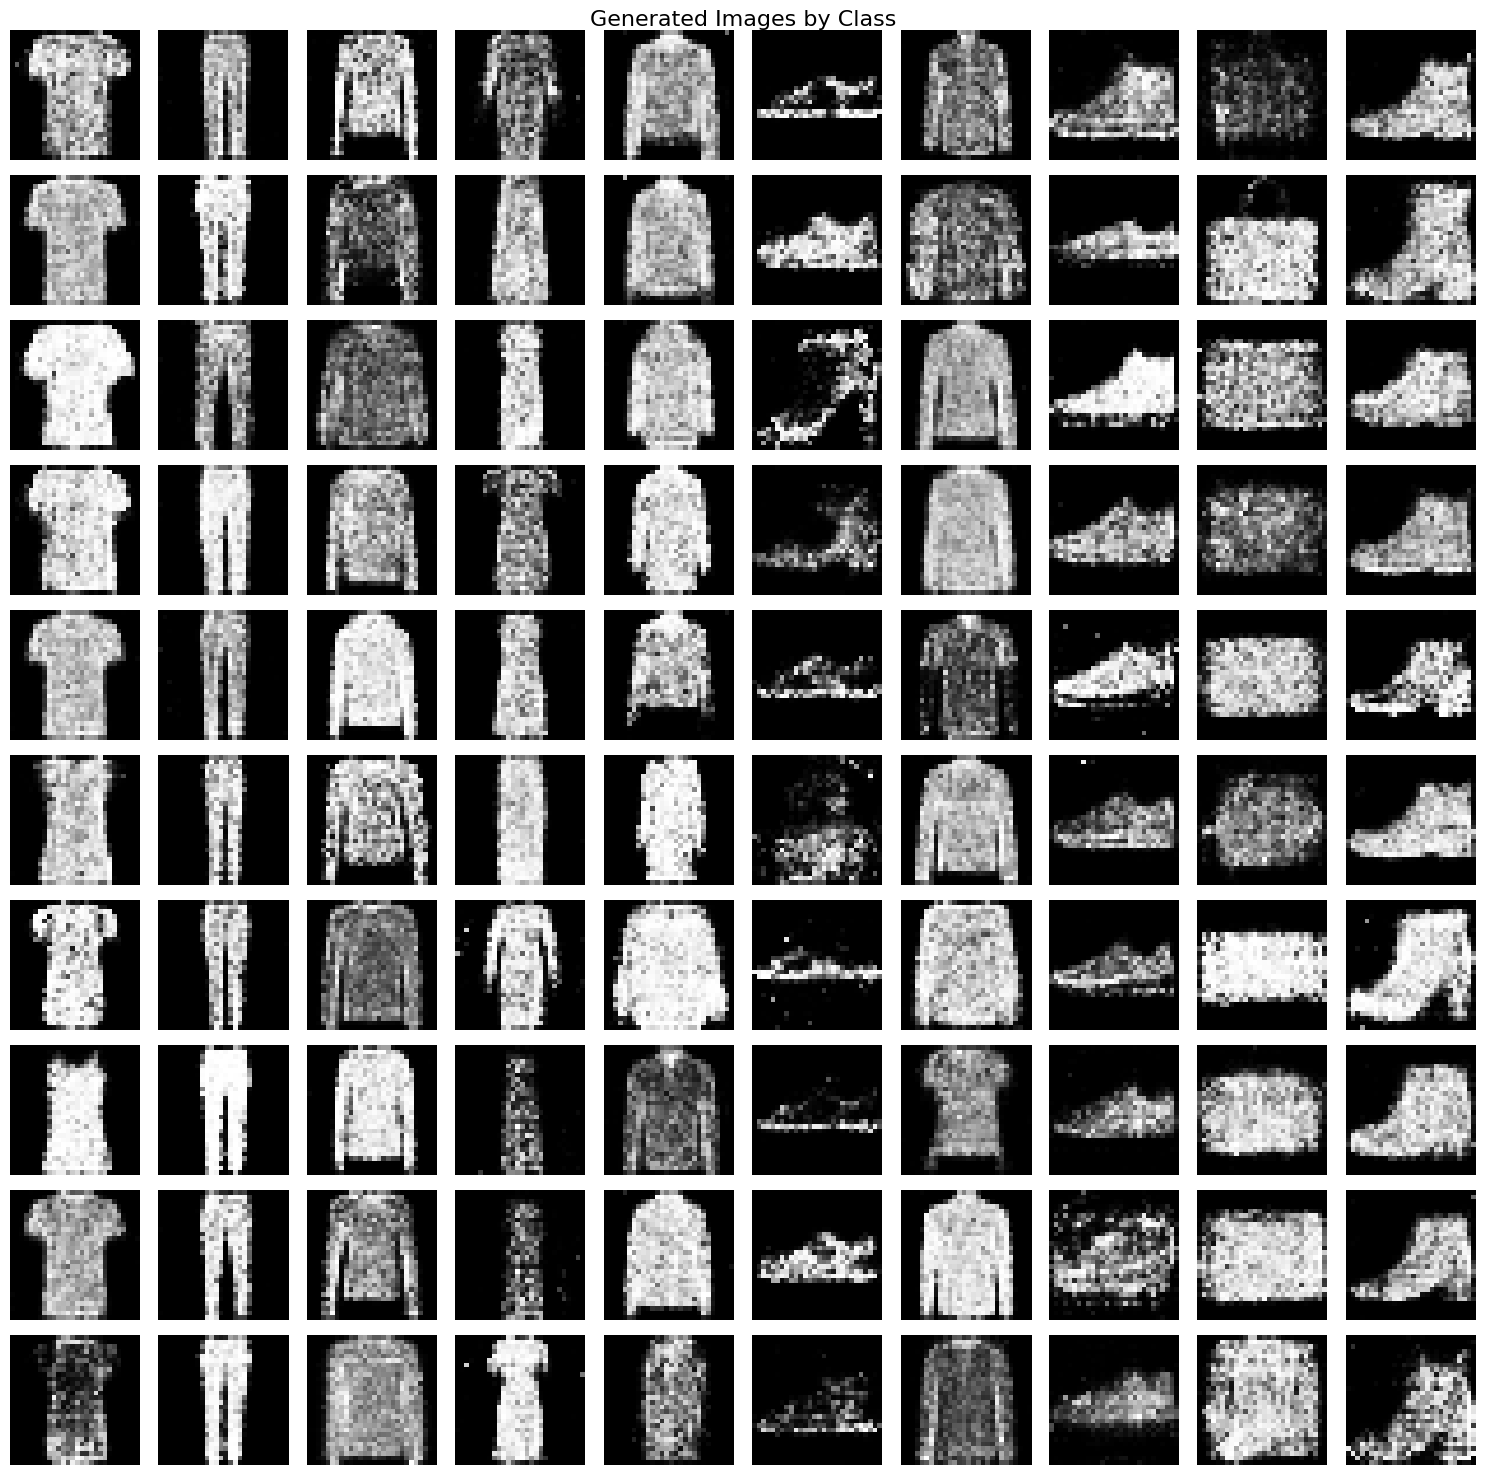

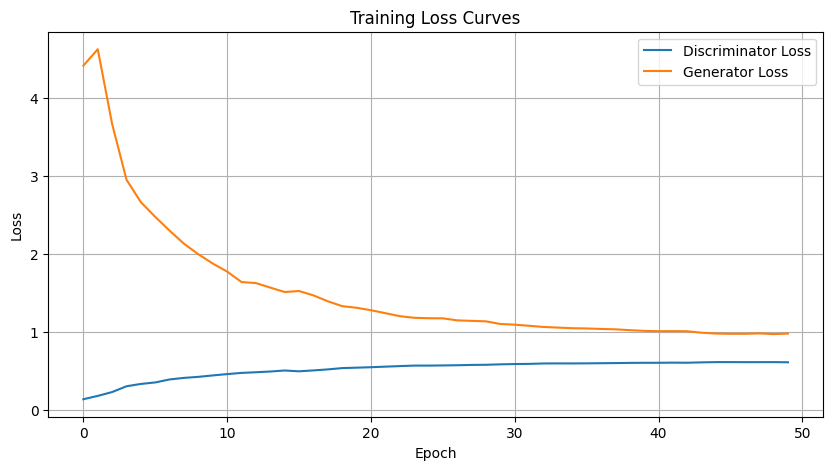


Training completed!


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from scipy.linalg import sqrtm
from sklearn.metrics import accuracy_score

# -----------------------------
# 1. 超参数
# -----------------------------
batch_size = 128
z_dim = 100
num_classes = 10
lr = 0.0002
epochs = 50  # 增加训练轮数
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -----------------------------
# 2. 数据加载 (Fashion-MNIST)
# -----------------------------
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.FashionMNIST(root="./data", train=True, transform=transform, download=True)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# 加载测试集用于评估
test_dataset = datasets.FashionMNIST(root="./data", train=False, transform=transform, download=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# -----------------------------
# 3. 模型定义
# -----------------------------
class Generator(nn.Module):
    def __init__(self, z_dim, num_classes, img_shape=28*28):
        super().__init__()
        self.label_emb = nn.Embedding(num_classes, num_classes)
        self.model = nn.Sequential(
            nn.Linear(z_dim + num_classes, 256),
            nn.ReLU(True),
            nn.Linear(256, 512),
            nn.ReLU(True),
            nn.Linear(512, img_shape),
            nn.Tanh()
        )
    def forward(self, z, labels):
        c = self.label_emb(labels)
        x = torch.cat([z, c], dim=1)
        img = self.model(x)
        return img.view(img.size(0), 1, 28, 28)


class Vsig(nn.Module):
    def __init__(self, init_sigma=0.28):
        super(Vsig, self).__init__()
        self.sigma = nn.Parameter(torch.tensor(init_sigma, dtype=torch.float32))
    
    def forward(self, input):
        eps = 1e-6
        sigma_safe = self.sigma + eps
        output = 1 / (1 + torch.exp(-input / sigma_safe))
        return output


class Discriminator(nn.Module):
    def __init__(self, num_classes, img_shape=28*28):
        super().__init__()
        self.label_emb = nn.Embedding(num_classes, num_classes)
        self.model = nn.Sequential(
            nn.Linear(img_shape + num_classes, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 1)
        )
        self.vsig = Vsig()  # 可学习的sigmoid激活
    
    def forward(self, img, labels):
        c = self.label_emb(labels)
        x = torch.cat([img.view(img.size(0), -1), c], dim=1)
        logits = self.model(x)
        output = self.vsig(logits)  # 应用可学习的sigmoid
        return output
# -----------------------------
# 4. 评估分类器（用于计算Inception Score和分类准确率）
# -----------------------------
class Classifier(nn.Module):
    """简单的分类器用于评估生成图像"""
    def __init__(self, num_classes):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
    
    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.model(x)

def train_classifier():
    """训练一个分类器用于评估"""
    print("Training classifier for evaluation...")
    classifier = Classifier(num_classes).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(classifier.parameters(), lr=0.001)
    
    classifier.train()
    for epoch in range(5):
        correct = 0
        total = 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = classifier(imgs)
            loss = criterion(outputs, labels)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
        
        acc = 100 * correct / total
        print(f"Classifier Epoch {epoch+1}/5, Accuracy: {acc:.2f}%")
    
    return classifier

# -----------------------------
# 5. 质量评价指标
# -----------------------------
def calculate_inception_score(gen_imgs, classifier, n_split=10, eps=1e-16):
    """
    计算Inception Score (IS)
    IS越高表示生成图像质量越好且多样性越高
    """
    classifier.eval()
    with torch.no_grad():
        preds = torch.softmax(classifier(gen_imgs), dim=1).cpu().numpy()
    
    # 分割成多个部分计算
    split_scores = []
    n_part = preds.shape[0] // n_split
    
    for i in range(n_split):
        part = preds[i * n_part:(i + 1) * n_part]
        py = np.mean(part, axis=0)  # 边际分布
        scores = []
        for j in range(part.shape[0]):
            pyx = part[j]
            scores.append(np.sum(pyx * np.log(pyx / (py + eps) + eps)))
        split_scores.append(np.exp(np.mean(scores)))
    
    return np.mean(split_scores), np.std(split_scores)

def calculate_fid(real_features, fake_features):
    """
    计算Fréchet Inception Distance (FID)
    FID越低表示生成图像与真实图像分布越接近
    """
    mu1, sigma1 = real_features.mean(axis=0), np.cov(real_features, rowvar=False)
    mu2, sigma2 = fake_features.mean(axis=0), np.cov(fake_features, rowvar=False)
    
    ssdiff = np.sum((mu1 - mu2) ** 2.0)
    covmean = sqrtm(sigma1.dot(sigma2))
    
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    
    fid = ssdiff + np.trace(sigma1 + sigma2 - 2.0 * covmean)
    return fid

def extract_features(imgs, model):
    """提取特征用于FID计算"""
    model.eval()
    with torch.no_grad():
        # 使用分类器的倒数第二层作为特征
        x = imgs.view(imgs.size(0), -1)
        for layer in list(model.model.children())[:-1]:
            x = layer(x)
        return x.cpu().numpy()

def calculate_mode_score(gen_labels, num_classes):
    """
    计算模式覆盖率
    衡量生成器是否能生成所有类别的样本
    """
    unique_labels = len(np.unique(gen_labels))
    mode_coverage = unique_labels / num_classes
    return mode_coverage

def calculate_conditional_accuracy(G, classifier, num_samples=1000):
    """
    计算条件准确率
    衡量生成的图像是否符合给定的类别标签
    """
    G.eval()
    classifier.eval()
    
    all_true_labels = []
    all_pred_labels = []
    
    with torch.no_grad():
        for _ in range(num_samples // num_classes):
            z = torch.randn(num_classes, z_dim, device=device)
            labels = torch.arange(0, num_classes, device=device)
            gen_imgs = G(z, labels)
            
            outputs = classifier(gen_imgs)
            _, predicted = torch.max(outputs.data, 1)
            
            all_true_labels.extend(labels.cpu().numpy())
            all_pred_labels.extend(predicted.cpu().numpy())
    
    accuracy = accuracy_score(all_true_labels, all_pred_labels)
    return accuracy

def evaluate_gan(G, D, classifier, test_loader, num_samples=1000):
    """综合评估GAN性能"""
    print("\n" + "="*50)
    print("Evaluating GAN Performance...")
    print("="*50)
    
    G.eval()
    
    # 1. 生成样本
    with torch.no_grad():
        z = torch.randn(num_samples, z_dim, device=device)
        gen_labels = torch.randint(0, num_classes, (num_samples,), device=device)
        gen_imgs = G(z, gen_labels)
    
    # 2. Inception Score
    is_mean, is_std = calculate_inception_score(gen_imgs, classifier)
    print(f"Inception Score: {is_mean:.4f} ± {is_std:.4f}")
    
    # 3. 条件准确率
    cond_acc = calculate_conditional_accuracy(G, classifier, num_samples)
    print(f"Conditional Accuracy: {cond_acc*100:.2f}%")
    
    # 4. 模式覆盖率
    mode_cov = calculate_mode_score(gen_labels.cpu().numpy(), num_classes)
    print(f"Mode Coverage: {mode_cov*100:.2f}%")
    
    # 5. FID Score
    # 提取真实图像特征
    real_features_list = []
    for imgs, _ in test_loader:
        imgs = imgs.to(device)
        features = extract_features(imgs, classifier)
        real_features_list.append(features)
        if len(real_features_list) * batch_size >= num_samples:
            break
    real_features = np.vstack(real_features_list)[:num_samples]
    
    # 提取生成图像特征
    fake_features = extract_features(gen_imgs, classifier)
    
    fid_score = calculate_fid(real_features, fake_features)
    print(f"FID Score: {fid_score:.4f}")
    
    # 6. 判别器置信度
    with torch.no_grad():
        d_real_conf = D(gen_imgs, gen_labels).mean().item()
    print(f"Discriminator Confidence on Generated: {d_real_conf:.4f}")
    
    print("="*50 + "\n")
    
    return {
        'is_mean': is_mean,
        'is_std': is_std,
        'cond_acc': cond_acc,
        'mode_cov': mode_cov,
        'fid': fid_score,
        'd_conf': d_real_conf
    }

# -----------------------------
# 6. 初始化模型与优化器
# -----------------------------
G = Generator(z_dim, num_classes).to(device)
D = Discriminator(num_classes).to(device)
criterion = nn.BCELoss()
optimizer_G = optim.Adam(G.parameters(), lr=lr, betas=(0.5, 0.999))
optimizer_D = optim.Adam(D.parameters(), lr=lr, betas=(0.5, 0.999))

# 训练评估分类器
classifier = train_classifier()

# -----------------------------
# 7. 训练循环（带评估）
# -----------------------------
history = {'d_loss': [], 'g_loss': [], 'metrics': []}

for epoch in range(epochs):
    G.train()
    D.train()
    
    epoch_d_loss = 0
    epoch_g_loss = 0
    num_batches = 0
    
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        batch_size = imgs.size(0)

        # 真/假标签
        real = torch.ones(batch_size, 1, device=device)
        fake = torch.zeros(batch_size, 1, device=device)

        # 训练判别器 D
        z = torch.randn(batch_size, z_dim, device=device)
        fake_labels = torch.randint(0, num_classes, (batch_size,), device=device)
        fake_imgs = G(z, fake_labels)

        real_loss = criterion(D(imgs, labels), real)
        fake_loss = criterion(D(fake_imgs.detach(), fake_labels), fake)
        d_loss = (real_loss + fake_loss) / 2

        optimizer_D.zero_grad()
        d_loss.backward()
        optimizer_D.step()

        # 训练生成器 G
        z = torch.randn(batch_size, z_dim, device=device)
        gen_labels = torch.randint(0, num_classes, (batch_size,), device=device)
        gen_imgs = G(z, gen_labels)
        g_loss = criterion(D(gen_imgs, gen_labels), real)

        optimizer_G.zero_grad()
        g_loss.backward()
        optimizer_G.step()
        
        epoch_d_loss += d_loss.item()
        epoch_g_loss += g_loss.item()
        num_batches += 1

    avg_d_loss = epoch_d_loss / num_batches
    avg_g_loss = epoch_g_loss / num_batches
    history['d_loss'].append(avg_d_loss)
    history['g_loss'].append(avg_g_loss)
    
    print(f"Epoch [{epoch+1}/{epochs}] | D loss: {avg_d_loss:.4f} | G loss: {avg_g_loss:.4f}")
    
    # 每10个epoch评估一次
    if (epoch + 1) % 10 == 0:
        metrics = evaluate_gan(G, D, classifier, test_loader)
        history['metrics'].append(metrics)

# -----------------------------
# 8. 最终评估
# -----------------------------
final_metrics = evaluate_gan(G, D, classifier, test_loader)

# -----------------------------
# 9. 可视化结果
# -----------------------------
# 生成每个类别的样本
G.eval()
with torch.no_grad():
    z = torch.randn(num_classes * 10, z_dim, device=device)
    labels = torch.arange(0, num_classes, device=device).repeat(10)
    gen_imgs = G(z, labels).cpu()

# 绘制生成样本网格
fig, axes = plt.subplots(num_classes, 10, figsize=(15, 15))
for i in range(num_classes):
    for j in range(10):
        idx = i * 10 + j
        axes[i, j].imshow(gen_imgs[idx].squeeze() * 0.5 + 0.5, cmap='gray')
        axes[i, j].axis('off')
        if j == 0:
            axes[i, j].set_ylabel(f'Class {i}', fontsize=12)

plt.suptitle('Generated Images by Class', fontsize=16)
plt.tight_layout()
plt.show()

# 绘制训练损失曲线
plt.figure(figsize=(10, 5))
plt.plot(history['d_loss'], label='Discriminator Loss')
plt.plot(history['g_loss'], label='Generator Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Curves')
plt.legend()
plt.grid(True)
plt.show()

print("\nTraining completed!")